<a href="https://colab.research.google.com/github/dvdm12/DFS_BFS_SEARCH/blob/master/MNIST_PRACTICE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np
import time

In [24]:
(x_train, y_train), (x_test, y_test)=tf.keras.datasets.mnist.load_data()

print(f"training model: {x_train.shape} , {y_train.shape}")
print(f"testing model: {x_test.shape} , {y_test.shape}")

training model: (60000, 28, 28) , (60000,)
testing model: (10000, 28, 28) , (10000,)


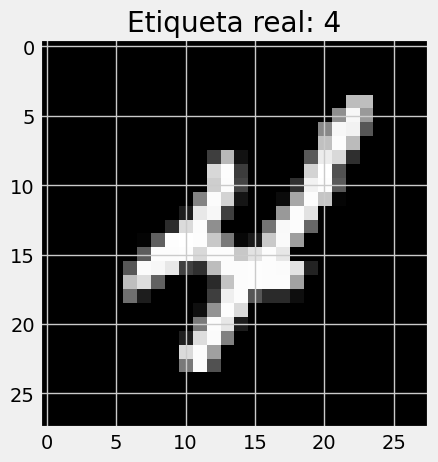

In [25]:
plt.imshow(x_train[9], cmap='gray')
plt.title(f"Etiqueta real: {y_train[9]}")
plt.show()

In [26]:
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print(f"Max: {x_train.max()}")
print(f"training model: {x_train.shape} , {y_train.shape}")
print(f"testing model: {x_test.shape} , {y_test.shape}")

Max: 1.0
training model: (60000, 28, 28, 1) , (60000,)
testing model: (10000, 28, 28, 1) , (10000,)


In [27]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

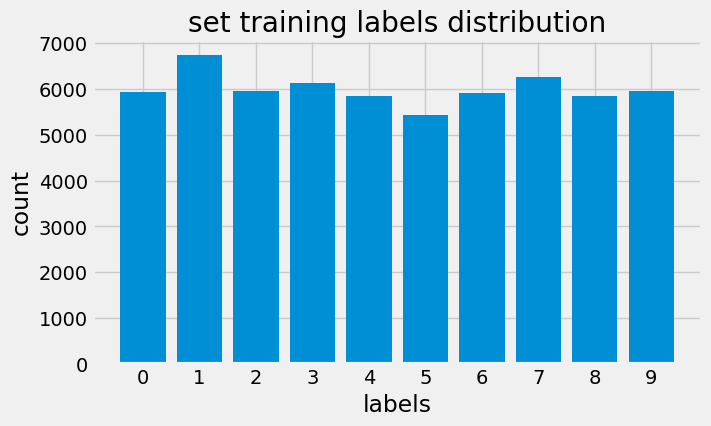

In [18]:
values_train , count_train = np.unique(y_train, return_counts=True)

plt.figure(figsize=(7,4))
plt.bar(values_train, count_train)
plt.title('set training labels distribution')
plt.xlabel('labels')
plt.ylabel('count')
plt.xticks(values_train)
plt.show()

In [28]:
# 1. Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Configuración de Callbacks (Parada Temprana)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 3. Entrenamiento
start_time = time.time()

history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

training_time = time.time() - start_time
print(f"\nTiempo de entrenamiento: {training_time:.2f} segundos")

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9033 - loss: 0.3290 - val_accuracy: 0.9778 - val_loss: 0.0682
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9828 - loss: 0.0570 - val_accuracy: 0.9828 - val_loss: 0.0503
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9891 - loss: 0.0355 - val_accuracy: 0.9850 - val_loss: 0.0430
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.9922 - loss: 0.0255 - val_accuracy: 0.9867 - val_loss: 0.0374
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9952 - loss: 0.0159 - val_accuracy: 0.9845 - val_loss: 0.0485
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9957 - loss: 0.0132 - val_accuracy: 0.9866 - val_loss: 0.0415
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9977 - loss: 0.0080 - val_accuracy: 0.9857 - val_loss: 0.0520
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9983 -

In [29]:
print(f"Valor máximo en x_train: {x_train.max()}") # Debería ser 1.0
print(f"Valor promedio en x_train: {x_train.mean():.4f}") # Debería ser ~0.13

Valor máximo en x_train: 1.0
Valor promedio en x_train: 0.1307


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


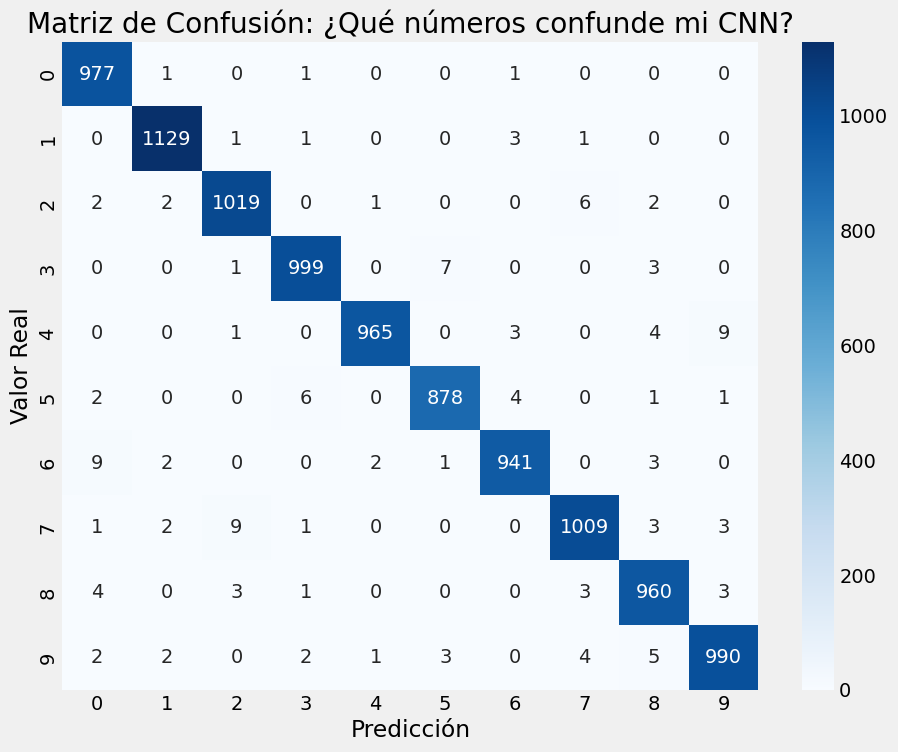


Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Obtener las predicciones
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# 2. Mostrar la Matriz de Confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión: ¿Qué números confunde mi CNN?')
plt.show()

print("\nReporte de Clasificación:\n")
print(classification_report(y_test, y_pred_classes))


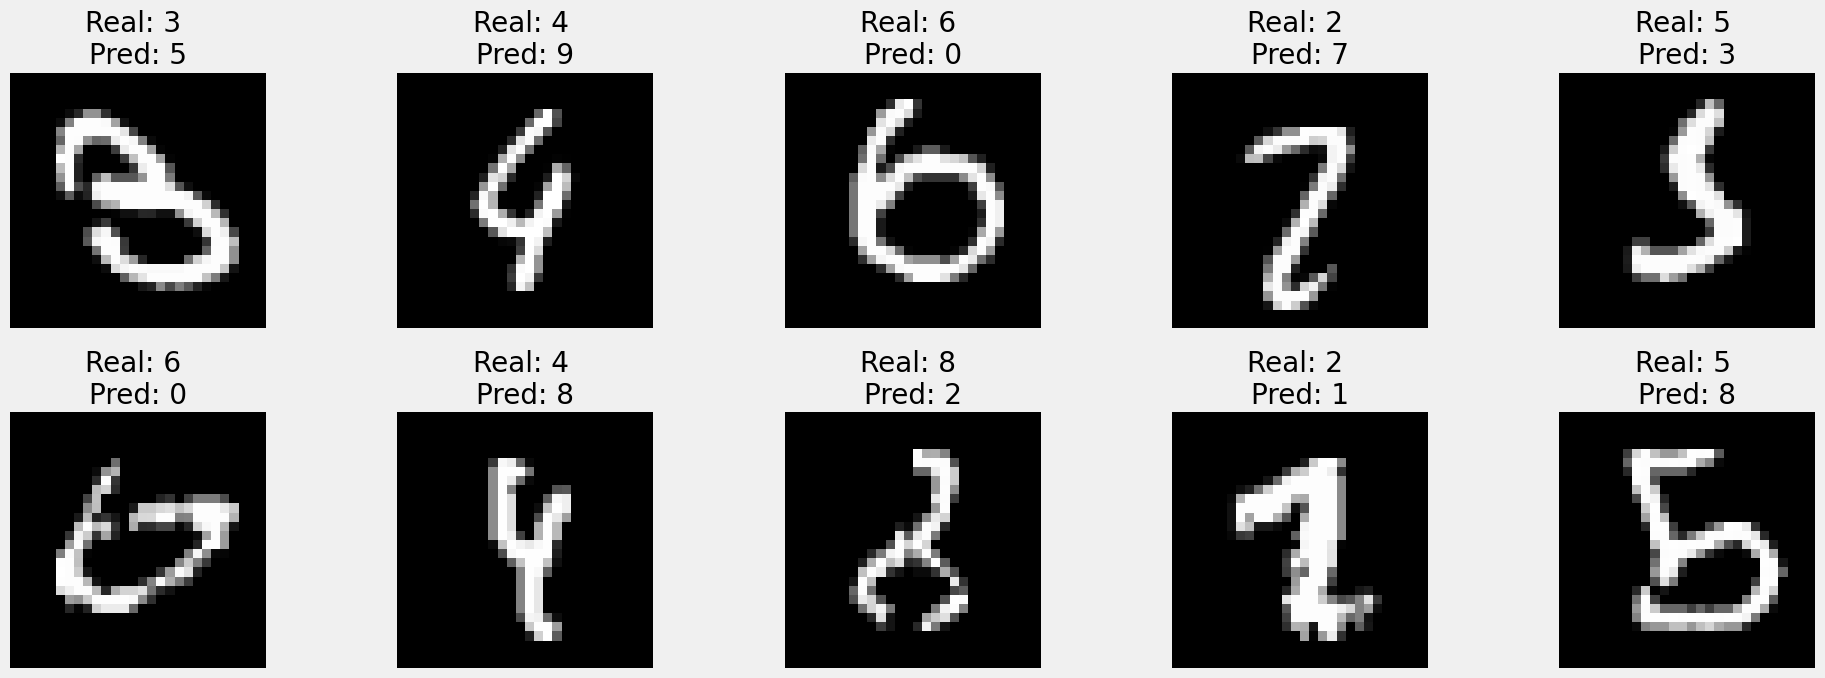

In [35]:
# 1. Identificar los índices de los errores
errores_idx = np.flatnonzero(y_pred_classes != y_test)

# 2. Configurar la visualización (mostraremos los primeros 10 errores)
plt.figure(figsize=(20, 7))
for i, idx in enumerate(errores_idx[:10]):
    plt.subplot(2, 5, i + 1)
    # Mostramos la imagen (recordando que tiene forma 28x28x1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Real: {y_test[idx]} \nPred: {y_pred_classes[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

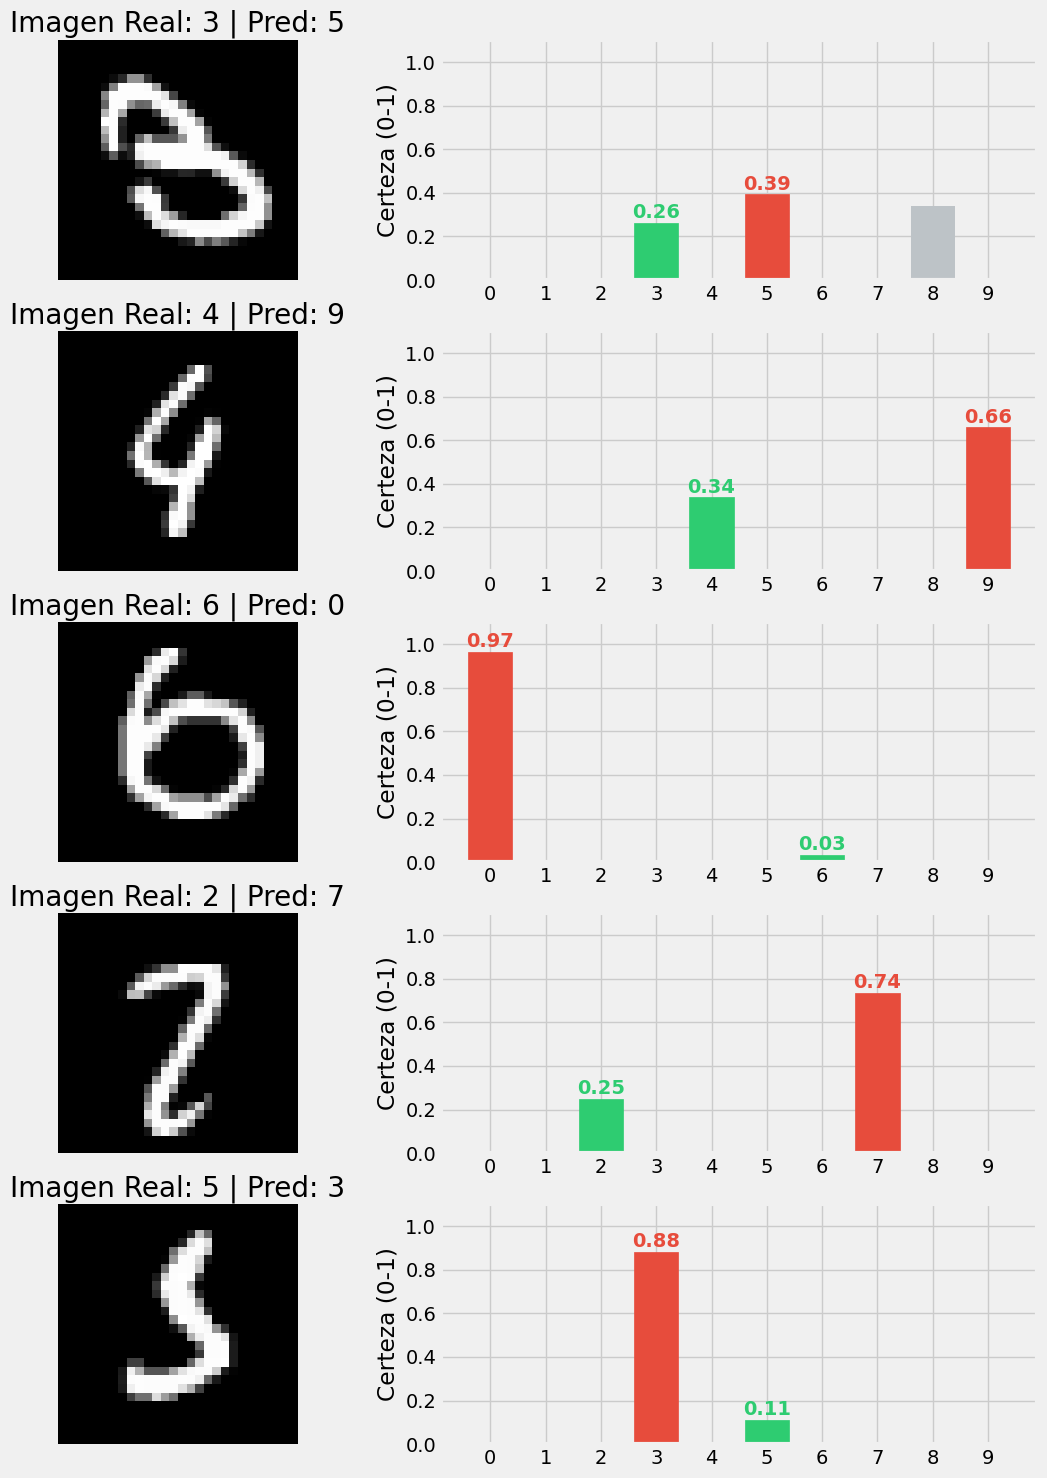

In [40]:
num_errores = 5
fig, axs = plt.subplots(num_errores, 2, figsize=(12, num_errores * 3))

for i, idx in enumerate(errores_idx[:num_errores]):
    # --- Subplot Izquierdo: La Imagen ---
    axs[i, 0].imshow(x_test[idx].reshape(28, 28), cmap='gray')
    axs[i, 0].set_title(f"Imagen Real: {y_test[idx]} | Pred: {y_pred_classes[idx]}")
    axs[i, 0].axis('off')

    # --- Subplot Derecho: Cuantificación Softmax ---
    probs = y_pred[idx]
    clase_real = y_test[idx]
    clase_pred = y_pred_classes[idx]

    # Dibujamos las barras
    barras = axs[i, 1].bar(range(10), probs, color='#bdc3c7') # Gris por defecto
    barras[clase_pred].set_color('#e74c3c') # Rojo para la predicción errónea
    barras[clase_real].set_color('#2ecc71')  # Verde para la respuesta correcta

    # Detalles técnicos de la gráfica
    axs[i, 1].set_ylim(0, 1.1) # Espacio para el texto
    axs[i, 1].set_xticks(range(10))
    axs[i, 1].set_ylabel('Certeza (0-1)')

    # Añadir el valor exacto sobre la barra de la predicción y la real
    axs[i, 1].text(clase_pred, probs[clase_pred] + 0.02, f'{probs[clase_pred]:.2f}',
                   ha='center', color='#e74c3c', fontweight='bold')
    axs[i, 1].text(clase_real, probs[clase_real] + 0.02, f'{probs[clase_real]:.2f}',
                   ha='center', color='#2ecc71', fontweight='bold')

plt.tight_layout()
plt.show()